In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('/content/drive/MyDrive/AIML_lab_sem4/exp2,3,4/customer_churn_dataset.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Tenure_Months,SubscriptionType,MonthlyCharges,TotalCharges,PaymentMethod,SupportTickets,ContractType,Churn
0,CUST1000,Male,49,54,Standard,99.33,4912.77,Net Banking,1,Two Year,0
1,CUST1001,Female,56,8,Standard,12.01,604.59,Debit Card,2,Two Year,0
2,CUST1002,Male,66,27,Basic,57.62,2019.39,Cash,4,Two Year,0
3,CUST1003,Male,69,27,Premium,97.08,4848.88,Credit Card,7,Two Year,0
4,CUST1004,Male,49,34,Standard,54.69,4334.26,Credit Card,9,One Year,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        200 non-null    object 
 1   Gender            200 non-null    object 
 2   Age               200 non-null    int64  
 3   Tenure_Months     200 non-null    int64  
 4   SubscriptionType  200 non-null    object 
 5   MonthlyCharges    200 non-null    float64
 6   TotalCharges      200 non-null    float64
 7   PaymentMethod     200 non-null    object 
 8   SupportTickets    200 non-null    int64  
 9   ContractType      200 non-null    object 
 10  Churn             200 non-null    int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 17.3+ KB


In [5]:
df = df.drop(columns=['CustomerID'])


In [6]:
df = df.dropna()


In [7]:
df = pd.get_dummies(df, drop_first=True)


In [8]:
from sklearn.model_selection import train_test_split



In [9]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)


In [12]:
model.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [13]:
y_pred = model.predict(X_test)


In [14]:
y_pred

array([0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0])

In [15]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.75
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        33
           1       0.29      0.29      0.29         7

    accuracy                           0.75        40
   macro avg       0.57      0.57      0.57        40
weighted avg       0.75      0.75      0.75        40



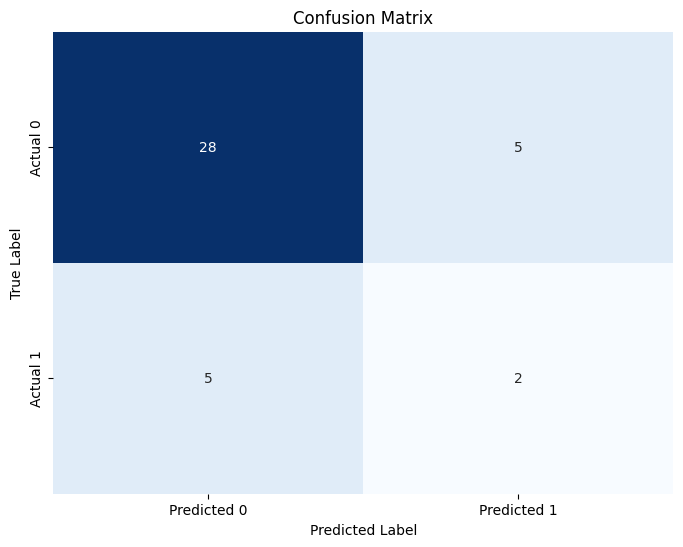

In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

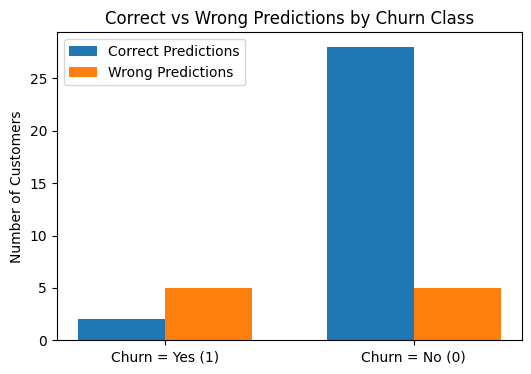

In [18]:

true_correct = np.sum((y_test == 1) & (y_pred == 1))
true_wrong   = np.sum((y_test == 1) & (y_pred == 0))
false_correct = np.sum((y_test == 0) & (y_pred == 0))
false_wrong   = np.sum((y_test == 0) & (y_pred == 1))

labels = ['Churn = Yes (1)', 'Churn = No (0)']
correct = [true_correct, false_correct]
wrong = [true_wrong, false_wrong]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(6, 4))
plt.bar(x - width/2, correct, width, label='Correct Predictions')
plt.bar(x + width/2, wrong, width, label='Wrong Predictions')

plt.xticks(x, labels)
plt.ylabel("Number of Customers")
plt.title("Correct vs Wrong Predictions by Churn Class")
plt.legend()
plt.show()


In [19]:
import pickle

model_filename = 'logistic_regression_model.pkl'
with open('/content/drive/MyDrive/AIML_lab_sem4/exp2,3,4/customerchurn', 'wb') as file:
    pickle.dump(model, file)

print(f"Model successfully saved to {model_filename}")

Model successfully saved to logistic_regression_model.pkl
